In [ ]:
# function for pip installing all the libraries:
def install_libraries():
    %pip install -q -U -r requirements.txt


In [1]:
import torch

torch.mps.empty_cache()  # similar to cuda.empty_cache()

In [12]:
# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA
import turftopic
from turftopic import ClusteringTopicModel, KeyNMF
from sklearn.cluster import HDBSCAN, KMeans
from umap import UMAP
from turftopic.vectorizers.spacy import TokenCountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon




os.environ["OPENAI_API_KEY"] = "sk-a1sY6cAN-hutzhoijNj55ViTOK_2ma9L1fMISWaitiT3BlbkFJQoS4SbHlO13RCoiiMl4NnjFRj8kH0XffrYQQRklSAA"

## Reading in the data

In [ ]:
import pandas as pd


#Dyadic and full story for both field and simulated
full_df_with_embeddings_field = pd.read_parquet("../data/TEXT/processed/story_sentiment_scores.parquet")
full_df_with_embeddings_simulated = pd.read_parquet("../data/TEXT/processed/story_sentiment_scores_simulated.parquet")
interaction_df_with_embeddings = pd.read_parquet("../data/TEXT/processed/dyadic_sentiment_scores_simulated.parquet")
interaction_df_with_embeddings_user = pd.read_parquet("../data/TEXT/processed/dyadic_sentiment_scores.parquet")

#npy embeddings for full stories
embeddings_field = np.load("../data/TEXT/processed/story_embeddings_jina_field_full.npy")
embeddings_user = np.load("../data/TEXT/processed/story_user_embeddings_jina_field_full.npy")
embeddings_ai = np.load("../data/TEXT/processed/story_ai_embeddings_jina_field_full.npy")


#Corpus for full stories
corpus_field = full_df_with_embeddings_field["full_story"].tolist()
user_field = full_df_with_embeddings_field["full_user"].tolist()
ai_field = full_df_with_embeddings_field["full_ai"].tolist()


FileNotFoundError: [Errno 2] No such file or directory: '../data/TEXT/story_sentiment_scores.parquet'

In [7]:

#print column names
print(interaction_df_with_embeddings_user.columns)
print(interaction_df_with_embeddings.columns)
print(full_df_with_embeddings_simulated.columns)
print(full_df_with_embeddings_field.columns)


Index(['timestamp', 'user', 'ai', 'combined_prompt', 'client_id',
       'workshop_id', 'language', 'conversation_id', 'edit_distance',
       'user_embedding', 'ai_embedding', 'turn', 'pct_turn',
       'user_sentiment_score', 'ai_sentiment_score'],
      dtype='object')
Index(['turn', 'user', 'ai', 'client_id', 'workshop_id', 'conversation_id',
       'timestamp', 'user_embedding', 'ai_embedding', 'pct_turn',
       'user_sentiment_score', 'ai_sentiment_score'],
      dtype='object')
Index(['conversation_id', 'full_user', 'full_ai', 'client_id', 'workshop_id',
       'timestamp', 'full_story', 'full_story_embedding',
       'full_user_embedding', 'full_ai_embedding', 'full_user_sentiment',
       'full_ai_sentiment'],
      dtype='object')
Index(['conversation_id', 'full_user', 'full_ai', 'language', 'client_id',
       'workshop_id', 'timestamp', 'full_story', 'full_story_embedding',
       'full_user_embedding', 'full_ai_embedding', 'full_user_sentiment',
       'full_ai_sentiment'

## Checking the embeddings

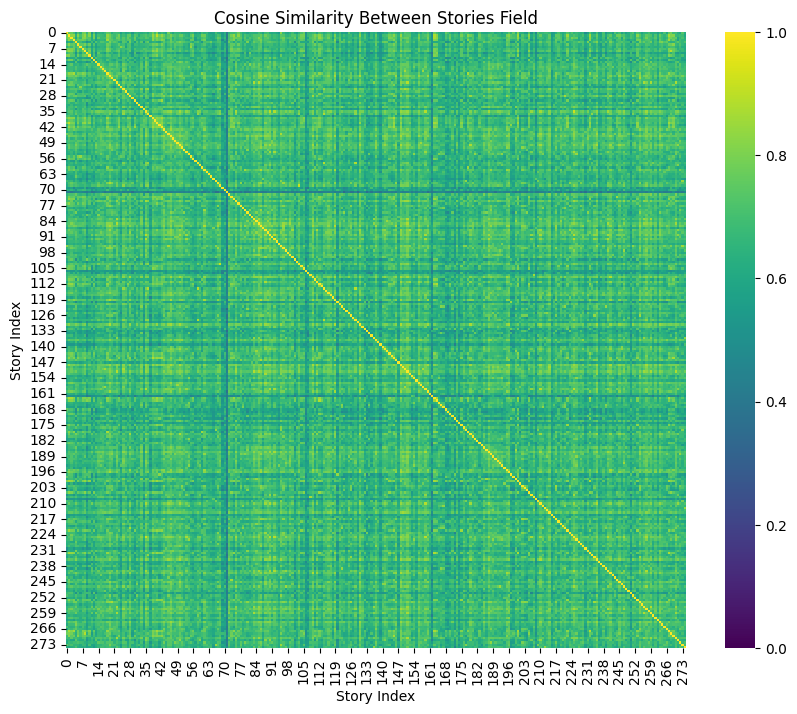

0.016990947 0.67083204


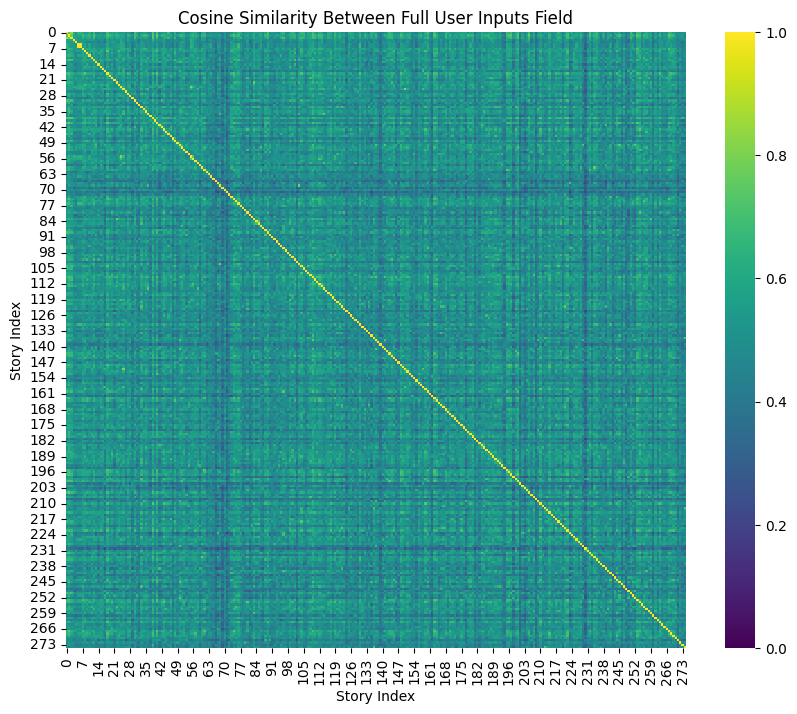

0.02097096 0.4989622


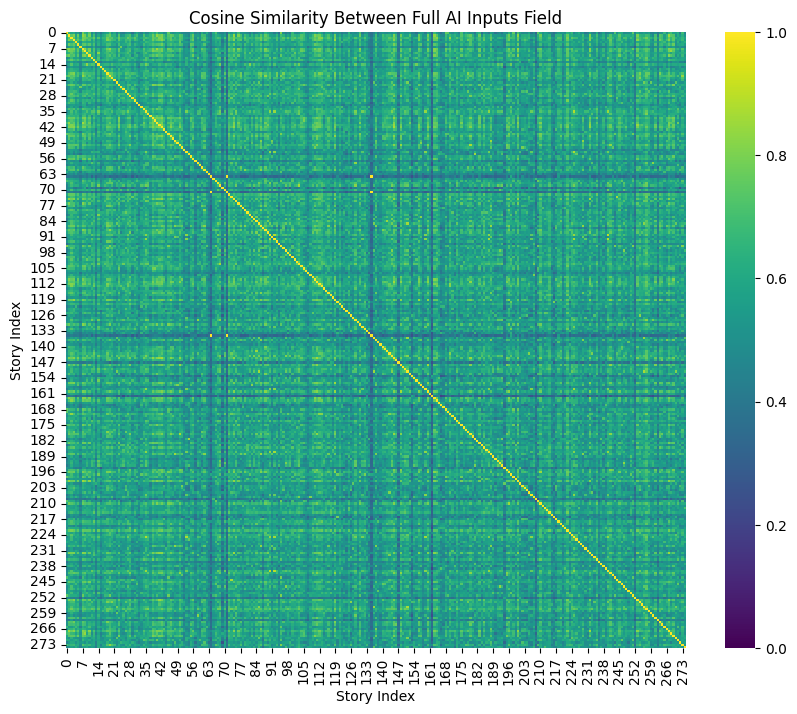

0.019402752 0.5695838


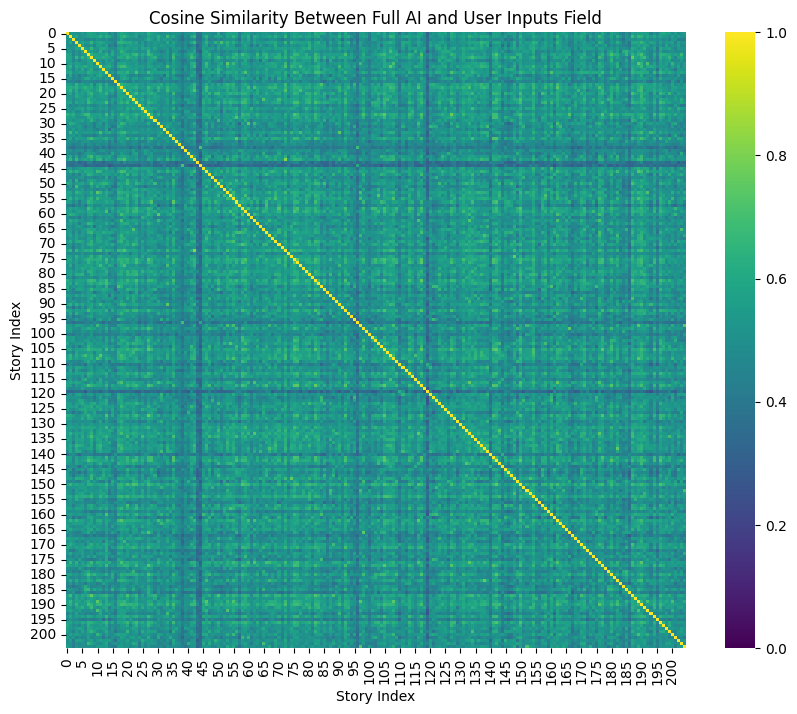

0.020419683582589294 0.5228930993954962


In [9]:
sim_matrix_field = cosine_similarity(embeddings_field)
sim_matrix_field_full_user = cosine_similarity(embeddings_user)
sim_matrix_field_full_ai = cosine_similarity(embeddings_ai)
full_embeddings_ai_user = np.concatenate([full_df_with_embeddings_field["full_user_embedding"].tolist(), full_df_with_embeddings_field["full_ai_embedding"].tolist()], axis=1)
sim_matrix_field_full_ai_user = cosine_similarity(full_embeddings_ai_user)


# sim_matrix_field = cosine_similarity(full_df_with_embeddings_field["embedding_jina"].tolist())
# sim_matrix_field_full_user = cosine_similarity(full_df_with_embeddings_field["user_embedding_jina"].tolist())
# sim_matrix_field_full_ai = cosine_similarity(full_df_with_embeddings_field["ai_embedding_jina"].tolist())
# full_embeddings_ai_user = np.concatenate([full_df_with_embeddings_field["user_embedding_jina"].tolist(), full_df_with_embeddings_field["ai_embedding_jina"].tolist()], axis=1)
# sim_matrix_field_full_ai_user = cosine_similarity(full_embeddings_ai_user)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix_field, cmap="viridis", vmin=0, vmax=1)
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.title("Cosine Similarity Between Stories Field")
plt.show()
print(np.std(embeddings_field, axis=0).mean(), np.mean(sim_matrix_field))  

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix_field_full_user, cmap="viridis", vmin=0, vmax=1)
plt.title("Cosine Similarity Between Full User Inputs Field")
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.show()
print(np.std(embeddings_user, axis=0).mean(), np.mean(sim_matrix_field_full_user))

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix_field_full_ai, cmap="viridis", vmin=0, vmax=1)
plt.title("Cosine Similarity Between Full AI Inputs Field")
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.show()
print(np.std(embeddings_ai, axis=0).mean(), np.mean(sim_matrix_field_full_ai))  #


plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix_field_full_ai_user, cmap="viridis", vmin=0, vmax=1)
plt.title("Cosine Similarity Between Full AI and User Inputs Field")
plt.xlabel("Story Index")
plt.ylabel("Story Index")
plt.show()
print(np.std(np.concatenate([full_df_with_embeddings_field["full_user_embedding"].tolist(), full_df_with_embeddings_field["full_ai_embedding"].tolist()], axis=1), axis=0).mean(), np.mean(sim_matrix_field_full_ai_user))

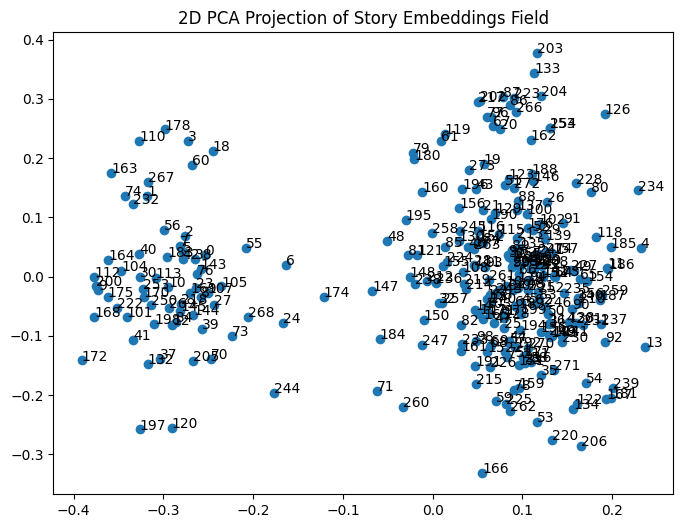

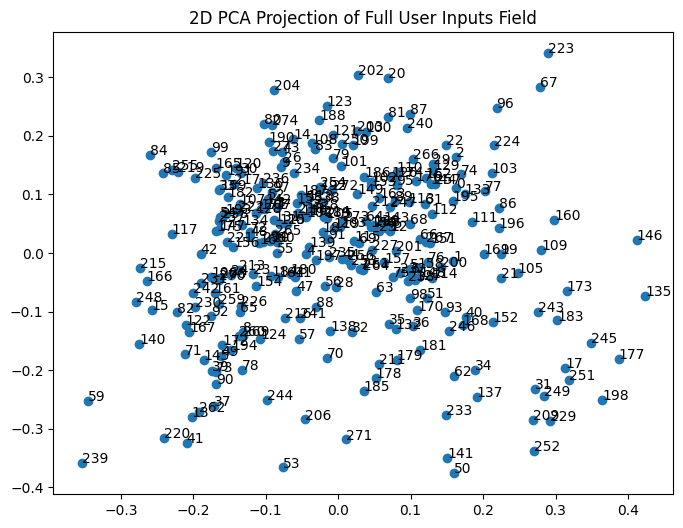

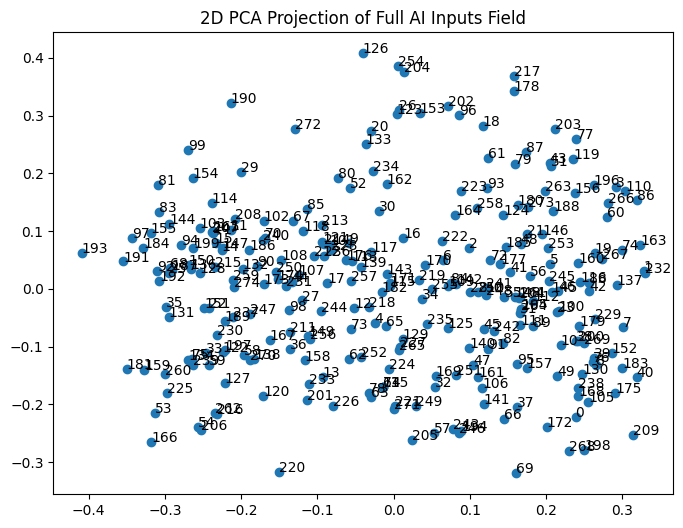

In [10]:
X_2d = PCA(n_components=2).fit_transform(embeddings_field)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1])
for i, txt in enumerate(range(len(X_2d))):
    plt.annotate(txt, (X_2d[i, 0], X_2d[i, 1]))
plt.title("2D PCA Projection of Story Embeddings Field")
plt.show()

X_2d_field_user = PCA(n_components=2).fit_transform(embeddings_user)
plt.figure(figsize=(8, 6))
plt.scatter(X_2d_field_user[:, 0], X_2d_field_user[:, 1])
for i, txt in enumerate(range(len(X_2d_field_user))):
    plt.annotate(txt, (X_2d_field_user[i, 0], X_2d_field_user[i, 1]))
plt.title("2D PCA Projection of Full User Inputs Field")
plt.show()


X_2d_field_ai = PCA(n_components=2).fit_transform(embeddings_ai)
plt.figure(figsize=(8, 6))
plt.scatter(X_2d_field_ai[:, 0], X_2d_field_ai[:, 1])
for i, txt in enumerate(range(len(X_2d_field_ai))):
    plt.annotate(txt, (X_2d_field_ai[i, 0], X_2d_field_ai[i, 1]))
plt.title("2D PCA Projection of Full AI Inputs Field")
plt.show()


### Loading encoder

In [ ]:
# Load the instructed multilingual E5 with asymmetric prompts per KeyNMF docs
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer(
    "intfloat/multilingual-e5-large-instruct",
    prompts={
        "query":   "Instruct: Retrieve relevant keywords from the given document. Query: ",
        "passage": "Passage: "
    },
    # Documents must be encoded as queries; words (terms) use the passage prompt
    default_prompt_name="query",
)

# Field data E5 topic modelling analysis

### Full story analysis using KeyNMF

In [ ]:
# 2) Fit KeyNMF
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(corpus_field)

# 3) Prepare the TopicData
topic_data_field = model.prepare_topic_data(corpus_field)

# 4) Quick built-in plots (no extra deps)
topic_data_field.figures.topic_barcharts()
topic_data_field.figures.document_map()
topic_data_field.print_topics()

In [ ]:
# transform the corpus to get document-topic distributions
doc_topic_field_story = model.transform(corpus_field)
#normalize the document-topic distribution to a probability distribution
P_field = doc_topic_field_story / doc_topic_field_story.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_field = (P_field > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_field = entropy(P_field.T)

print(f"Mean breadth field: {breadth_field.mean():.3f}")
print(f"Mean entropy field: {entropy_scores_field.mean():.3f}")

In [ ]:
#jensen-shannon divergence within the field corpus
n_f = P_field.shape[0]
js_within_field = []
for i in range(n_f):
    for j in range(i + 1, n_f):
        js_within_field.append(jensenshannon(P_field[i], P_field[j]))

mean_js_within_field = np.mean(js_within_field)
print(f"Mean JS within field: {mean_js_within_field:.3f}")

In [ ]:
model = ClusteringTopicModel(
    dimensionality_reduction=UMAP(metric="cosine"),
    clustering=KMeans(n_clusters=5, random_state=0), 
    feature_importance="centroid"
)
doc_topic = model.fit_transform(corpus_field, embeddings=sim_matrix_field)

[11:14:19] Term extraction done.                                                                     ]8;id=534777;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py\cluster.py]8;;\:]8;id=941615;file:///Users/halfidaldal/Documents/PENPAL_analysis/venv/lib/python3.13/site-packages/turftopic/models/cluster.py#455\455]8;;\

Output()

### Full user input analysis using E5

In [ ]:
# 2) Fit KeyNMF
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(user_field)

# 3) Prepare the TopicData
topic_data_field_user = model.prepare_topic_data(user_field)

# 4) Quick built-in plots (no extra deps)
topic_data_field_user.figures.topic_barcharts()
topic_data_field_user.figures.document_map()
topic_data_field_user.print_topics()

In [ ]:
doc_topic_field_user = model.transform(user_field)
#normalize the document-topic distribution to a probability distribution
P_field_user = doc_topic_field_user / doc_topic_field_user.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_field_user = (P_field_user > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_field_user = entropy(P_field_user.T)

print(f"Mean breadth field_user: {breadth_field_user.mean():.3f}")
print(f"Mean entropy field_user: {entropy_scores_field_user.mean():.3f}")

In [ ]:
(doc_topic_field_user.sum(axis=1) == 0).sum() 
idx_zero = np.where(doc_topic_field_user.sum(axis=1) == 0)[0]
[user_field[i][:120] for i in idx_zero]
doc_topic_field_user.min()


In [ ]:
#jensen-shannon divergence within the field corpus
n_f = P_field_user.shape[0]
js_within_field_user = []
for i in range(n_f):
    for j in range(i + 1, n_f):
        js_within_field_user.append(jensenshannon(P_field_user[i], P_field_user[j]))
        
mean_js_within_field_user = np.mean(js_within_field_user)
print(f"Mean JS within field user: {mean_js_within_field_user:.3f}")

### Full AI input analysis using E5

In [ ]:
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(ai_field)

# 3) Prepare the TopicData
topic_data_field_ai = model.prepare_topic_data(ai_field)

# 4) Quick built-in plots (no extra deps)
topic_data_field_ai.figures.topic_barcharts()
topic_data_field_ai.figures.document_map()
topic_data_field_ai.print_topics()

In [ ]:
doc_topic_field_ai = model.transform(ai_field)
#normalize the document-topic distribution to a probability distribution
P_field_ai = doc_topic_field_ai / doc_topic_field_ai.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_field_ai = (P_field_ai > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_field_ai = entropy(P_field_ai.T)

print(f"Mean breadth field: {breadth_field_ai.mean():.3f}")
print(f"Mean entropy field: {entropy_scores_field_ai.mean():.3f}")

In [ ]:
# jensen-shannon divergence within the simulated corpus
n_s = P_field_ai.shape[0]
js_within_field_ai = []
for i in range(n_s):
    for j in range(i + 1, n_s):
        js_within_field_ai.append(jensenshannon(P_field_ai[i], P_field_ai[j]))

mean_js_within_field_ai = np.mean(js_within_field_ai)
print(f"Mean JS within field AI: {mean_js_within_field_ai:.3f}")


# Simulated data E5 topic modelling analysis

### Full story analysis using KeyNMF

In [ ]:
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(corpus_sim)
# 3) Prepare the TopicData
topic_data_sim = model.prepare_topic_data(corpus_sim)
# 4) Quick built-in plots (no extra deps)
topic_data_sim.figures.topic_barcharts()
topic_data_sim.figures.document_map()
topic_data_sim.print_topics()

In [ ]:
doc_topic_sim_story = model.transform(corpus_sim)
#normalize the document-topic distribution to a probability distribution
P_sim = doc_topic_sim_story / doc_topic_sim_story.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_sim = (P_sim > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_sim = entropy(P_sim.T)

print(f"Mean breadth simulated: {breadth_sim.mean():.3f}")
print(f"Mean entropy simulated: {entropy_scores_sim.mean():.3f}")

In [ ]:
#jensen-shannon divergence within the simulated corpus
n_s = P_sim.shape[0]
js_within_sim = []
for i in range(n_s):
    for j in range(i + 1, n_s):
        js_within_sim.append(jensenshannon(P_sim[i], P_sim[j]))

### Simulated user input analysis

In [ ]:
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(user_sim)
# 3) Prepare the TopicData
topic_data_sim_user = model.prepare_topic_data(user_sim)
# 4) Quick built-in plots (no extra deps)
topic_data_sim_user.figures.topic_barcharts()
topic_data_sim_user.figures.document_map()
topic_data_sim_user.print_topics()

### Simulated AI input analysis

In [ ]:
model = KeyNMF(n_components=10, encoder=encoder, top_n=10, random_state=42)
model.fit(ai_sim)
# 3) Prepare the TopicData
topic_data_sim_ai = model.prepare_topic_data(ai_sim)
# 4) Quick built-in plots (no extra deps)
topic_data_sim_ai.figures.topic_barcharts()
topic_data_sim_ai.figures.document_map()

topic_data_sim_ai.print_topics()

In [ ]:
doc_topic_sim_ai = model.transform(ai_sim)
#normalize the document-topic distribution to a probability distribution
P_sim_ai = doc_topic_sim_ai / doc_topic_sim_ai.sum(axis=1, keepdims=True)
# compute breadth of topics
breadth_sim_ai = (P_sim_ai > 0).sum(axis=1)
# 2. Compute entropy for each story
entropy_scores_sim_ai = entropy(P_sim_ai.T)

print(f"Mean breadth simulated AI: {breadth_sim_ai.mean():.3f}")
print(f"Mean entropy simulated AI: {entropy_scores_sim_ai.mean():.3f}")

In [ ]:
# jensen-shannon divergence within the simulated ai_corpus
n_sa = P_sim_ai.shape[0]
js_within_ai_sim = []
for i in range(n_sa):
    for j in range(i + 1, n_sa):
        js_within_ai_sim.append(jensenshannon(P_sim_ai[i], P_sim_ai[j]))

mean_js_within_ai_sim = np.mean(js_within_ai_sim)
print(f"Mean JS within simulated AI: {mean_js_within_ai_sim:.3f}")


In [ ]:
clusterer = HDBSCAN(min_cluster_size=4, min_samples=1)
model = ClusteringTopicModel(
  encoder=l2v,
  dimensionality_reduction=UMAP(metric="cosine"),
  clustering=clusterer,
  feature_importance="centroid"
)
doc_topic = model.fit_transform(ai_sim, embeddings=story_embeddings_ai_sim)

In [ ]:
model.print_topics()
topics_df = model.topics_df()

# Show interactive cluster map
fig = model.plot_clusters_datamapplot()
fig.show()
# Merge down to 5 top-level topics using "smallest→closest" (Top2Vec’s strategy)
model.reduce_topics(n_reduce_to=5, reduction_method="smallest", metric="cosine")

print(model.hierarchy)
model.hierarchy.cut(max_depth=2).plot_tree()

# Comparing field vs simulated

### Full story

#### Breadth

In [ ]:
# Breadth = count of topics with nonzero weight. A story loading on 5 topics is more exploratory than one loading on 1–2

plt.boxplot([breadth_field, breadth_sim], labels=["Field", "Simulated"])
plt.title("Breadth of Topics in Field vs Simulated Stories")
plt.ylabel("Breadth of Topics")
plt.show()

plt.boxplot([breadth_field_ai, breadth_sim_ai], labels=["Field AI", "Simulated AI"])
plt.title("Breadth of Topics in Field vs Simulated AI Stories")
plt.ylabel("Breadth of Topics")
plt.show()

#### Entropy

In [ ]:
#Entropy measures how evenly the story spreads across its active topics. A one-topic story has entropy = 0; a perfectly 5-way split has entropy = log 5.
plt.boxplot([entropy_scores_field, entropy_scores_sim], labels=["Field", "Simulated"])
plt.title("Entropy of Topics in Field vs Simulated Stories")
plt.ylabel("Entropy")
plt.show()

plt.boxplot([entropy_scores_field_ai, entropy_scores_sim_ai], labels=["Field AI", "Simulated AI"])
plt.title("Entropy of Topics in Field vs Simulated AI Inputs")
plt.ylabel("Entropy")
plt.show()

#### Jensen-Shannon divergence

In [ ]:
mean_js_within_field = np.mean(js_within_field)
mean_js_within_sim = np.mean(js_within_sim)

print(f"Mean JS within field: {mean_js_within_field:.3f}")
print(f"Mean JS within sim  : {mean_js_within_sim:.3f}")
print(f"Mean JS within field AI: {mean_js_within_field_ai:.3f}")
print(f"Mean JS within simulated AI: {mean_js_within_ai_sim:.3f}")

all_P = np.vstack([P_field, P_sim])
N = all_P.shape[0]
js_mat = np.zeros((N, N))
for i in range(N):
    for j in range(i+1, N):
        d = jensenshannon(all_P[i], all_P[j])
        js_mat[i, j] = js_mat[j, i] = d

sns.heatmap(js_mat, cmap="viridis")
plt.title("Pairwise JS-divergence (field first, then sim)")
plt.show()

In [ ]:
# Compute means for each metric and store in a DataFrame
df_meaned_metrics = pd.DataFrame({
    "field_metrics": {"breadth": breadth_field.mean(),
        "entropy": entropy_scores_field.mean(),
        "js_within": mean_js_within_field,
        "breadth_ai": breadth_field_ai.mean(),
        "entropy_ai": entropy_scores_field_ai.mean(),
        "js_within_ai": mean_js_within_field_ai},
    "sim_metrics": {"breadth": breadth_sim.mean(),
        "entropy": entropy_scores_sim.mean(),
        "js_within": mean_js_within_sim,
        "breadth_ai": breadth_sim_ai.mean(),
        "entropy_ai": entropy_scores_sim_ai.mean(),
        "js_within_ai": mean_js_within_ai_sim}
})